# EDA CDC Places Dataset  

## Introduction

The Centers for Disease Control and Prevention (CDC) provides a dataset called "Places" that contains information about various health-related metrics at the county and city level across the United States. This dataset includes information on health outcomes, health behaviors, clinical care, social and economic factors, and physical environment.

This exploratory data analysis (EDA) focuses on understanding the structure of the CDC Places dataset, to identify patterns, trends, and potential areas for further analysis that can support the master dataset join. Key objectives include validating primary keys, identifying data quality issues (such as missingness), and assessing the distribution of core health metrics.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 

# Read The CSV file 

In [2]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw"/ "cdc_places_raw.csv"

df = pd.read_csv(data_path)

print(f"Data loaded successfully")

Data loaded successfully


# Exploratory Data Analysis (EDA)

In [3]:
df.head()

,year,stateabbr,statedesc,countyname,countyfips,locationname,datasource,category,measure,data_value_unit,...,low_confidence_limit,high_confidence_limit,totalpopulation,totalpop18plus,geolocation,locationid,categoryid,measureid,datavaluetypeid,short_question_text
0,2023,AL,Alabama,Autauga,1001,1001020100,BRFSS,Prevention,Current lack of health insurance among adults ...,%,...,7.4,12.3,1775,1370,POINT (-86.4915648 32.4819731),1001020100,PREVENT,ACCESS2,CrdPrv,Health Insurance
1,2023,AL,Alabama,Autauga,1001,1001020100,BRFSS,Health Outcomes,Arthritis among adults,%,...,27.2,34.0,1775,1370,POINT (-86.4915648 32.4819731),1001020100,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis
2,2023,AL,Alabama,Autauga,1001,1001020100,BRFSS,Health Risk Behaviors,Binge drinking among adults,%,...,12.1,17.7,1775,1370,POINT (-86.4915648 32.4819731),1001020100,RISKBEH,BINGE,CrdPrv,Binge Drinking
3,2023,AL,Alabama,Autauga,1001,1001020100,BRFSS,Health Outcomes,High blood pressure among adults,%,...,37.1,45.7,1775,1370,POINT (-86.4915648 32.4819731),1001020100,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure
4,2023,AL,Alabama,Autauga,1001,1001020100,BRFSS,Prevention,Taking medicine to control high blood pressure...,%,...,74.9,80.4,1775,1370,POINT (-86.4915648 32.4819731),1001020100,PREVENT,BPMED,CrdPrv,High Blood Pressure Medication


In [4]:
df.shape

(3047284, 24)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3047284.0,2.022863e+03,3.438658e-01,2.022000e+03,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03
countyfips,3047284.0,2.710148e+04,1.593084e+04,1.001000e+03,1.210100e+04,2.616300e+04,3.909500e+04,5.604500e+04
locationname,3047284.0,2.710173e+10,1.593085e+10,1.001020e+09,1.210103e+10,2.616358e+10,3.909501e+10,5.604595e+10
data_value,3047284.0,2.601500e+01,2.337885e+01,3.000000e-01,9.000000e+00,1.690000e+01,3.460000e+01,9.820000e+01
data_value_footnote_symbol,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_value_footnote,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
low_confidence_limit,3047284.0,2.353609e+01,2.244689e+01,2.000000e-01,7.600000e+00,1.450000e+01,3.040000e+01,9.770000e+01
high_confidence_limit,3047284.0,2.857956e+01,2.424116e+01,3.000000e-01,1.040000e+01,1.950000e+01,3.890000e+01,9.860000e+01
totalpopulation,3047284.0,3.971712e+03,1.672655e+03,5.400000e+01,2.774000e+03,3.787000e+03,4.952000e+03,3.789200e+04
totalpop18plus,3047284.0,3.093981e+03,1.275032e+03,5.000000e+01,2.184000e+03,2.959000e+03,3.845000e+03,3.128000e+04


There appears to be two empty columens data_value_footnote_symbol and data_value_footnote. These columns should likely be dropped as they do not contain any useful information.

Population: totalpopulation and totalpop18plus have outliers. The 75th percentile is ~4,952, but the max is 37,892. This indicates some very large counties or high-population outliers. Range goes form 0.3 to 98.2 which is a massive spread of heath metrics. Ceate a histogram to see if there is a noral distribution or if the data is skewed.

countyfips and locationid are showing up with numerical statistics (mean, min, max).
Warning: Even though they are numbers, they are actually categorical identifiers. Do not use these in any mathematical calculations.

In [6]:
df.isnull().sum()

year                                0
stateabbr                           0
statedesc                           0
countyname                          0
countyfips                          0
locationname                        0
datasource                          0
category                            0
measure                             0
data_value_unit                     0
data_value_type                     0
data_value                          0
data_value_footnote_symbol    3047284
data_value_footnote           3047284
low_confidence_limit                0
high_confidence_limit               0
totalpopulation                     0
totalpop18plus                      0
geolocation                         0
locationid                          0
categoryid                          0
measureid                           0
datavaluetypeid                     0
short_question_text                 0
dtype: int64

In [7]:
df.dtypes

year                            int64
stateabbr                      object
statedesc                      object
countyname                     object
countyfips                      int64
locationname                    int64
datasource                     object
category                       object
measure                        object
data_value_unit                object
data_value_type                object
data_value                    float64
data_value_footnote_symbol    float64
data_value_footnote           float64
low_confidence_limit          float64
high_confidence_limit         float64
totalpopulation                 int64
totalpop18plus                  int64
geolocation                    object
locationid                      int64
categoryid                     object
measureid                      object
datavaluetypeid                object
short_question_text            object
dtype: object

Data is well structured with a few hidden traps. 

Identifiers countyfips, locationid, and year are treated as interges. Should convert to objects. 

Categories and objects category, measure, data_value_unit, and short_question_text are correctly identified as objects. These are primary grouping variables. 

The Missingness Confirmed: data_value_footnote_symbol and data_value_footnote are float64 but were empty in your previous summary. These are safe to drop or ignore.

Location/Geolocation: geolocation may be needed later for spatial mapping. 

## Visulization

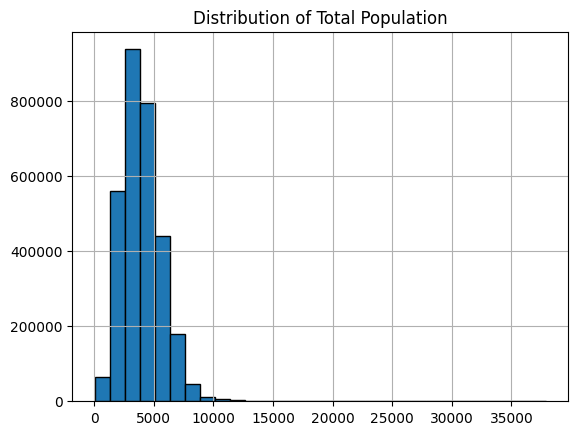

In [8]:
# histogram for population
df['totalpopulation'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Total Population')
plt.show()

totalpopulation shows a significant right-skew, consistent with typical county-level demographics

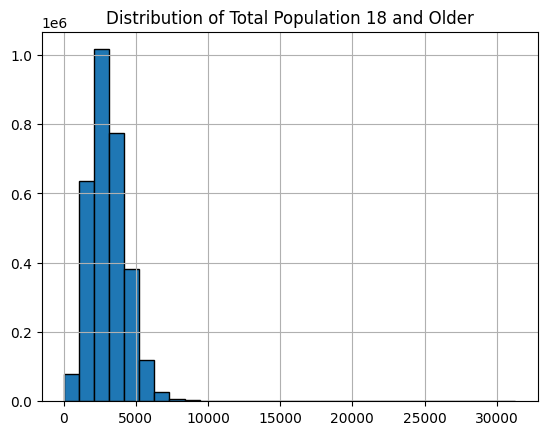

In [9]:
# histogram for population
df['totalpop18plus'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Total Population 18 and Older')
plt.show()

totalpop18plus is a direct subset of the totalpopulation, so it is expected that they share the same distribution shape. It confirms that the demographic composition across your counties is consistent—the outliers you see in the total population are present in the adult population as well.

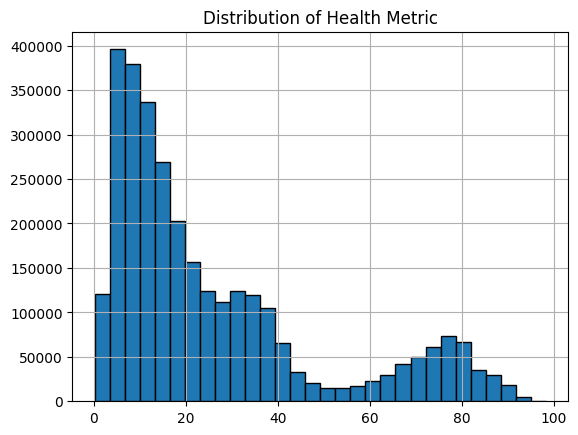

In [10]:
# histogram for health metric
df['data_value'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Health Metric')
plt.show()

data_value shows a bimodal (two-peak) distribution. Suggesting that health metric data isn't just one big blob; it likely represents two distinct types of regions or conditions

In [11]:
# Check which counties are in the "High-Risk" cluster (e.g., above 60)
high_risk = df[df['data_value'] > 60]
print(high_risk['stateabbr'].value_counts()) # See if one state dominates the high-risk group

stateabbr
CA    45418
TX    32435
NY    28683
FL    26431
OH    17046
IL    16891
MI    16576
GA    14646
NC    14467
VA    12330
NJ    11819
WA     9868
MA     9099
IN     9080
PA     8949
WI     8753
MN     8668
MO     8662
TN     8645
AZ     8559
MD     8121
CO     7717
AL     7506
LA     7243
SC     7182
OK     5857
OR     5475
IA     5141
CT     5033
KS     4414
MS     4095
AR     4018
UT     3841
NV     3762
NE     3043
NM     2885
KY     2860
WV     2810
ID     2486
HI     2400
ME     2257
NH     2026
MT     1758
DE     1428
RI     1415
SD     1375
ND     1287
DC     1153
VT     1135
AK      843
WY      814
Name: count, dtype: int64


the frequency of the data points closely mirrors the population distribution of the United States. States like California (CA), Texas (TX), and New York (NY) are at the top, while states with lower population densities like Wyoming (WY) and Alaska (AK) are at the bottom.

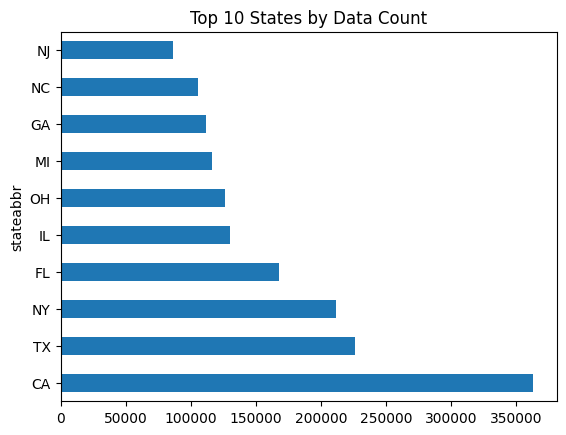

In [12]:
# show the state representation
df['stateabbr'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 States by Data Count')
plt.show()